# Install and import

In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

import torch
from torch_geometric.data import Data
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, EdgePooling
from torch_geometric.loader import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import gc

# Preprocess

In [ ]:
cap_names = ["15-3", "16-2", "18"]

capturas = {}

for i in cap_names:
  capturas[str(i)] = {}
  #cap = pd.read_csv(f"/content/unzipped_files/capture201108{str(i)}.csv", dtype={'Sport': object, 'Dport': object})
  cap = pd.read_csv(f"capture201108{str(i)}.csv", dtype={'Sport': object, 'Dport': object})
  cap_copy = cap.copy()
  #
  cap = cap.loc[(cap['Proto'] == "tcp") | (cap['Proto'] == "udp")]
  #
  keep_columns = [0,1,19,20,21,22,23,24,25,26,27,28,29,30,31,32]
  cap = cap.iloc[:, keep_columns]
  #
  cap_norm = cap[~cap['Label'].str.contains("From-Botnet")].copy()
  cap_norm['Label'] = cap_norm['Label'].str.contains('From-Botnet').astype(int)
  #
  cap_bot = cap[cap['Label'].str.contains("From-Botnet")].copy()
  cap_bot['Label'] = cap_bot['Label'].str.contains('From-Botnet').astype(int)
  #
  aux_bot=cap_bot.groupby(['SrcAddr', 'DstAddr']).agg({
    'Dur': 'mean',
    'TotPkts': 'mean',
    'TotBytes': 'mean',
    'TotAppByte': 'mean',
    'Rate': 'mean',
    'Label': 'max'
  }).reset_index()
  num_rows = 2*len(aux_bot)
  #
  capturas[str(i)]["original"] = cap_copy
  capturas[str(i)]["filter"] = cap
  capturas[str(i)]["normal"] = cap_norm
  capturas[str(i)]["bot"] = cap_bot
  #
  for j in range(30):
    np.random.seed(42+j*10)
    cap_subset = pd.concat([cap_bot, cap_norm.sample(n=num_rows)]).sample(frac=1).reset_index(drop=True)
    capturas[str(i)][f"cap_subset_{j:02}"] = cap_subset
  #
  del cap, cap_copy, cap_norm, cap_bot, aux_bot, cap_subset
  gc.collect()


In [ ]:
cap_names = ["15-3", "16-2", "18"]
subsets = {}

for j in range(30):
  subsets[j] = {}
  for i in cap_names:
    subsets[j][str(i)] = {}
    # Get all unique IPs from SrcAddr and DstAddr
    unique_ips = pd.unique(capturas[str(i)][f"cap_subset_{j:02}"][['SrcAddr', 'DstAddr']].values.ravel('K'))
    # Create a mapping from IP address to a unique node index
    ip_to_index = {ip: idx for idx, ip in enumerate(unique_ips)}

    # Group by SrcAddr to calculate sending-related features
    src_features = capturas[str(i)][f"cap_subset_{j:02}"].groupby('SrcAddr').agg({
        'SrcPkts': 'mean',
        'SrcBytes': 'mean',
        'SAppBytes': 'mean',
        'SrcRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as SrcAddr
    src_features = src_features.set_index('SrcAddr').reindex(unique_ips, fill_value=0).reset_index()

    # Group by DstAddr to calculate receiving-related features
    dst_features = capturas[str(i)][f"cap_subset_{j:02}"].groupby('DstAddr').agg({
        'DstPkts': 'mean',
        'DstBytes': 'mean',
        'DAppBytes': 'mean',
        'DstRate': 'mean'
    }).reset_index()
    # Add missing columns with zeros for nodes that do not appear as DstAddr
    dst_features = dst_features.set_index('DstAddr').reindex(unique_ips, fill_value=0).reset_index()

    # Merge src_features and dst_features based on unique IPs
    node_features = pd.merge(src_features, dst_features, left_on='SrcAddr', right_on='DstAddr', how='outer')#.fillna(0)
    # Reorganize columns to create the final node feature vector:
    # [SrcPkts, SrcBytes, SAppBytes, SrcRate, DstPkts, DstBytes, DAppBytes, DstRate]
    node_features = node_features[['SrcPkts', 'SrcBytes', 'SAppBytes', 'SrcRate', 'DstPkts', 'DstBytes', 'DAppBytes', 'DstRate']]
    # Convert node features to tensor
    node_features_tensor = torch.tensor(node_features.values, dtype=torch.float)

    # Group by SrcAddr and DstAddr to create edge features and labels
    edge_features = capturas[str(i)][f"cap_subset_{j:02}"].groupby(['SrcAddr', 'DstAddr']).agg({
        'Dur': 'mean',
        'TotPkts': 'mean',
        'TotBytes': 'mean',
        'TotAppByte': 'mean',
        'Rate': 'mean',
        'Label': 'max'
    }).reset_index()

    # Convert the SrcAddr and DstAddr pairs to edge indices
    edge_indices = torch.tensor([[ip_to_index[src], ip_to_index[dst]] for src, dst in zip(edge_features['SrcAddr'], edge_features['DstAddr'])], dtype=torch.long).t().contiguous()
    # Convert edge features to tensor
    edge_features_tensor = torch.tensor(edge_features[['Dur', 'TotPkts', 'TotBytes', 'TotAppByte', 'Rate']].values, dtype=torch.float)
    # Convert edge labels to tensor
    edge_labels_tensor = torch.tensor(edge_features['Label'].values, dtype=torch.long)

    subsets[j][str(i)]["unique_ips"] = unique_ips
    subsets[j][str(i)]["ip_to_index"] = ip_to_index
    subsets[j][str(i)]["node_features_tensor"] = node_features_tensor
    subsets[j][str(i)]["edge_indices"] = edge_indices
    subsets[j][str(i)]["edge_features_tensor"] = edge_features_tensor
    subsets[j][str(i)]["edge_labels_tensor"] = edge_labels_tensor


# Models

In [ ]:
# MODEL 1

class EGraphSAGE1(torch.nn.Module):
    def __init__(self, in_channels_node, in_channels_edge, hidden_channels, out_channels):
        super(EGraphSAGE1, self).__init__()

        # Node-wise GraphSAGE convolution layers
        self.conv1 = SAGEConv(in_channels_node, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)

        # Linear layer for combining node and edge features
        self.edge_mlp = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden_channels + in_channels_edge, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, out_channels)
        )

    def forward(self, x, edge_index, edge_attr):
        # Apply GraphSAGE convolutions to node features
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        # Extract the features for source and destination nodes of each edge
        row, col = edge_index
        src_features = x[row]
        dst_features = x[col]

        # Concatenate source, destination node features, and edge features
        edge_features = torch.cat([src_features, dst_features, edge_attr], dim=1)

        # Pass through the MLP for edge classification
        edge_logits = self.edge_mlp(edge_features)

        return edge_logits


# Loss function for edge classification (CrossEntropyLoss is typically used)
criterion = torch.nn.CrossEntropyLoss()



In [ ]:
# Parameters:
# Number of node features = 8
# Number of edge features = 5
# Hidden dimension size model1 = 64
# Number of classes for edge classification = 2

model1 = EGraphSAGE1(8, 5, 64, 2)
model1

EGraphSAGE1(
  (conv1): SAGEConv(8, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (edge_mlp): Sequential(
    (0): Linear(in_features=133, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [ ]:
# MODEL 2

# Define the E-GraphSAGE Model
class EGraphSAGE2(torch.nn.Module):
    def __init__(self, in_channels, edge_in_channels, hidden_channels1, hidden_channels2, out_channels):
        super(EGraphSAGE2, self).__init__()
        self.sage1 = SAGEConv(in_channels, hidden_channels1)
        self.sage2 = SAGEConv(hidden_channels1, hidden_channels2)

        # Linear layer for edge classification
        self.edge_fc = torch.nn.Linear(hidden_channels2*2 + edge_in_channels, out_channels)  # Concatenate node embeddings and edge features

    def forward(self, x, edge_index, edge_attr):
        # Step 1: Node embedding via GraphSAGE
        x = F.relu(self.sage1(x, edge_index))
        x = self.sage2(x, edge_index)

        # Step 2: Edge classification - Concatenate the embeddings of the source and target nodes
        edge_src = x[edge_index[0]]  # Embeddings for source nodes
        edge_dst = x[edge_index[1]]  # Embeddings for destination nodes

        # Concatenate source node, destination node embeddings, and edge features
        edge_features = torch.cat([edge_src, edge_dst, edge_attr], dim=1)

        # Step 3: Pass concatenated features through fully connected layer to predict edge class
        return self.edge_fc(edge_features)


# Step 3: Set up device
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [ ]:
# Parameters
# Number of node features = 8
# Number of edge features = 5
# Hidden dimension size 1 of model2 = 128
# Hidden dimension size 2 of model2 = 64
# Number of classes for edge classification = 2

model2 = EGraphSAGE2(8, 5, 128, 64, 2)
model2

EGraphSAGE2(
  (sage1): SAGEConv(8, 128, aggr=mean)
  (sage2): SAGEConv(128, 64, aggr=mean)
  (edge_fc): Linear(in_features=133, out_features=2, bias=True)
)

In [ ]:
def train(model, optimizer, loader):
    model.train()
    total_loss = 0

    for data in loader:
        optimizer.zero_grad()

        # Forward pass
        out = model(data.x, data.edge_index, data.edge_attr)

        # Compute loss (compare predictions with edge labels)
        loss = criterion(out, data.edge_label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def test(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0

    with torch.no_grad():
        for data in loader:
            # Forward pass
            out = model(data.x, data.edge_index, data.edge_attr)

            # Get predicted class (as argmax over output)
            pred = out.argmax(dim=1)

            # Store predictions and true labels
            all_preds.append(pred.cpu())
            all_labels.append(data.edge_label.cpu())

    # Concatenate all the predictions and labels
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Calculate accuracy, precision, recall, and f1-score
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)  # Use 'binary' for binary classification
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)

    return accuracy, precision, recall, f1, all_labels, all_preds


# Training and testing

In [ ]:
cap_names = ["15-3", "16-2", "18"]

df_losses = pd.DataFrame()

accuracy_t1_m1_l = []
precision_t1_m1_l = []
recall_t1_m1_l = []
f1_t1_m1_l = []
accuracy_t1_m2_l = []
precision_t1_m2_l = []
recall_t1_m2_l = []
f1_t1_m2_l = []
accuracy_t2_m1_l = []
precision_t2_m1_l = []
recall_t2_m1_l = []
f1_t2_m1_l = []
accuracy_t2_m2_l = []
precision_t2_m2_l = []
recall_t2_m2_l = []
f1_t2_m2_l = []

pred_test1 = {}
pred_test2 = {}


for j in range(30):
    print(j)
    pred_test1[j] = {}
    pred_test2[j] = {}

    train_data = Data(
      x = subsets[j]["15-3"]["node_features_tensor"],       # Node features
      edge_index = subsets[j]["15-3"]["edge_indices"],      # Edge index
      edge_attr = subsets[j]["15-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[j]["15-3"]["edge_labels_tensor"]   # Edge labels
    )
    train_loader1 = DataLoader([train_data], batch_size=1, shuffle=True)
    train_loader2 = DataLoader([train_data], batch_size=1, shuffle=True)

    test1_data = Data(
      x = subsets[j]["18"]["node_features_tensor"],       # Node features
      edge_index = subsets[j]["18"]["edge_indices"],      # Edge index
      edge_attr = subsets[j]["18"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[j]["18"]["edge_labels_tensor"]   # Edge labels
    )
    test1_loader = DataLoader([test1_data], batch_size=1)

    test2_data = Data(
      x = subsets[j]["16-2"]["node_features_tensor"],       # Node features
      edge_index = subsets[j]["16-2"]["edge_indices"],      # Edge index
      edge_attr = subsets[j]["16-2"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[j]["16-2"]["edge_labels_tensor"]   # Edge labels
    )
    test2_loader = DataLoader([test2_data], batch_size=1)

    # Parameters
    in_channels_node = train_data.x.size(1)  # Number of node features
    in_channels_edge = train_data.edge_attr.size(1)  # Number of edge features
    hidden_channels = 64  # Hidden dimension size model1
    hidden_channels1 = 128 # Hidden dimension size model2
    hidden_channels2 = 64 # Hidden dimension size model2
    out_channels = len(torch.unique(train_data.edge_label))  # Number of classes for edge classification

    # Initialize the model 1
    model1 = EGraphSAGE1(in_channels_node, in_channels_edge, hidden_channels, out_channels)
    optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.01)

    # Initialize the model 2
    model2 = EGraphSAGE2(in_channels_node, in_channels_edge, hidden_channels1, hidden_channels2, out_channels).to(device)
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

    # Training for multiple epochs
    num_epochs = 200
    loss1 = []
    loss2 = []
    for epoch in range(1, num_epochs + 1):
        loss1.append(train(model1, optimizer1, train_loader1))
        loss2.append(train(model2, optimizer2, train_loader2))
    df_losses = pd.concat([df_losses, pd.DataFrame({f"loss1_{j:02}": loss1, f"loss2_{j:02}": loss2})], axis=1)

    # Test 1
    accuracy_t1_m1, precision_t1_m1, recall_t1_m1, f1_t1_m1, all_labels_t1_m1, all_preds_t1_m1 = test(model1,test1_loader)
    accuracy_t1_m2, precision_t1_m2, recall_t1_m2, f1_t1_m2, all_labels_t1_m2, all_preds_t1_m2 = test(model2,test1_loader,)

    # Test 2
    accuracy_t2_m1, precision_t2_m1, recall_t2_m1, f1_t2_m1, all_labels_t2_m1, all_preds_t2_m1 = test(model1,test2_loader)
    accuracy_t2_m2, precision_t2_m2, recall_t2_m2, f1_t2_m2, all_labels_t2_m2, all_preds_t2_m2 = test(model2,test2_loader)

    accuracy_t1_m1_l.append(accuracy_t1_m1)
    precision_t1_m1_l.append(precision_t1_m1)
    recall_t1_m1_l.append(recall_t1_m1)
    f1_t1_m1_l.append(f1_t1_m1)

    accuracy_t1_m2_l.append(accuracy_t1_m2)
    precision_t1_m2_l.append(precision_t1_m2)
    recall_t1_m2_l.append(recall_t1_m2)
    f1_t1_m2_l.append(f1_t1_m2)

    accuracy_t2_m1_l.append(accuracy_t2_m1)
    precision_t2_m1_l.append(precision_t2_m1)
    recall_t2_m1_l.append(recall_t2_m1)
    f1_t2_m1_l.append(f1_t2_m1)

    accuracy_t2_m2_l.append(accuracy_t2_m2)
    precision_t2_m2_l.append(precision_t2_m2)
    recall_t2_m2_l.append(recall_t2_m2)
    f1_t2_m2_l.append(f1_t2_m2)

    pred_test1[j]["labels"] = all_labels_t1_m1
    pred_test1[j]["model1"] = all_preds_t1_m1
    pred_test1[j]["model2"] = all_preds_t1_m2

    pred_test2[j]["labels"] = all_labels_t2_m1
    pred_test2[j]["model1"] = all_preds_t2_m1
    pred_test2[j]["model2"] = all_preds_t2_m2


df_metrics_test1 = pd.DataFrame({'acc_m1': accuracy_t1_m1_l,
                                 'prec_m1': precision_t1_m1_l,
                                 'rec_m1': recall_t1_m1_l,
                                 'f1_m1': f1_t1_m1_l,
                                 'acc_m2': accuracy_t1_m2_l,
                                 'prec_m2': precision_t1_m2_l,
                                 'rec_m2': recall_t1_m2_l,
                                 'f1_m2': f1_t1_m2_l
                                 })

df_metrics_test2 = pd.DataFrame({'acc_m1': accuracy_t2_m1_l,
                                 'prec_m1': precision_t2_m1_l,
                                 'rec_m1': recall_t2_m1_l,
                                 'f1_m1': f1_t2_m1_l,
                                 'acc_m2': accuracy_t2_m2_l,
                                 'prec_m2': precision_t2_m2_l,
                                 'rec_m2': recall_t2_m2_l,
                                 'f1_m2': f1_t2_m2_l
                                 })


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


# Save results

In [ ]:
df_metrics_test1.to_csv("metrics_t1.csv")

In [ ]:
df_metrics_test2.to_csv("metrics_t2.csv")

In [ ]:
df_losses.to_csv("losses.csv")

In [ ]:
import pickle

with open('capturas.pkl', 'wb') as archivo:
    pickle.dump(capturas, archivo)

with open('subsets.pkl', 'wb') as archivo:
    pickle.dump(subsets, archivo)

with open('pred_test1.pkl', 'wb') as archivo:
    pickle.dump(pred_test1, archivo)

with open('pred_test2.pkl', 'wb') as archivo:
    pickle.dump(pred_test2, archivo)

# Postprocess

## Metrics

In [ ]:
df_metrics_test1 = pd.read_csv("/content/metrics_t1.csv").iloc[:,1:]
df_metrics_test2 = pd.read_csv("/content/metrics_t2.csv").iloc[:,1:]

In [ ]:
df_metrics_test1.describe()

,acc_m1,prec_m1,rec_m1,f1_m1,acc_m2,prec_m2,rec_m2,f1_m2
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.653750,0.389621,0.371617,0.366246,0.545895,0.103363,0.129703,0.111800
std,0.165375,0.399346,0.412026,0.394009,0.117273,0.244412,0.327527,0.276552
min,0.355649,0.000000,0.000000,0.000000,0.357759,0.000000,0.000000,0.000000
25%,0.535274,0.000000,0.000000,0.000000,0.461620,0.000000,0.000000,0.000000
50%,0.591893,0.349722,0.108911,0.161301,0.526116,0.000000,0.000000,0.000000
75%,0.772982,0.719749,0.801980,0.750652,0.568712,0.000000,0.000000,0.000000
max,0.956710,1.000000,0.930693,0.947917,0.845833,0.752066,1.000000,0.845188


In [ ]:
df_metrics_test2.describe()

,acc_m1,prec_m1,rec_m1,f1_m1,acc_m2,prec_m2,rec_m2,f1_m2
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.563244,0.356978,0.064706,0.096595,0.587008,0.439577,0.045098,0.076820
std,0.066688,0.356095,0.058518,0.072886,0.052725,0.421169,0.025305,0.044343
min,0.400000,0.000000,0.000000,0.000000,0.466667,0.000000,0.000000,0.000000
25%,0.535841,0.142857,0.058824,0.083333,0.557692,0.114583,0.058824,0.077692
50%,0.571591,0.250000,0.058824,0.095238,0.600000,0.291667,0.058824,0.097619
75%,0.611390,0.475000,0.058824,0.111111,0.626486,1.000000,0.058824,0.111111
max,0.644444,1.000000,0.235294,0.296296,0.659574,1.000000,0.058824,0.111111


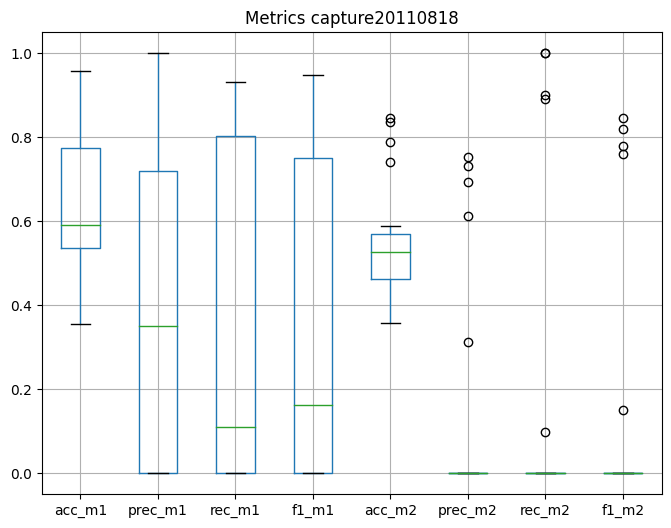

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df_metrics_test1.boxplot(column=['acc_m1', 'prec_m1', 'rec_m1', 'f1_m1', 'acc_m2', 'prec_m2', 'rec_m2', 'f1_m2'], figsize=(8, 6))
plt.title('Metrics capture20110818')
plt.show()



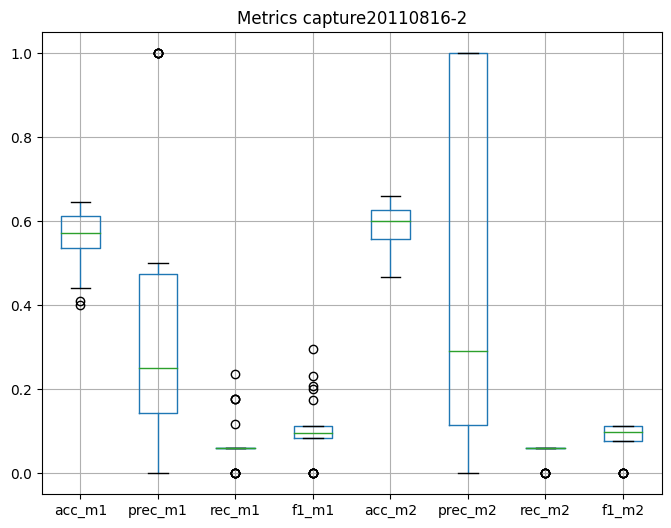

In [ ]:
plt.figure(figsize=(8,6))
df_metrics_test2.boxplot(column=['acc_m1', 'prec_m1', 'rec_m1', 'f1_m1', 'acc_m2', 'prec_m2', 'rec_m2', 'f1_m2'], figsize=(8, 6))
plt.title('Metrics capture20110816-2')
plt.show()


In [ ]:
import pickle

with open('pred_test1.pkl', 'rb') as archivo:
    pred_test1 = pickle.load(archivo)

with open('pred_test2.pkl', 'rb') as archivo:
    pred_test2 = pickle.load(archivo)

In [ ]:
#capture20110818:

for j in range(30):
  print("capture20110818 - run",j, "\n")
  print("labels:\n", pred_test1[j]["labels"])
  print("predictions with model1:\n", pred_test1[j]["model1"])
  print("predictions with model2:\n", pred_test1[j]["model2"])
  df1 = pd.DataFrame(df_metrics_test1.iloc[j,:])
  df1.columns=['values']
  # Agregar los índices correspondientes
  df1['metrics'] = ['acc', 'prec', 'rec', 'f1', 'acc', 'prec', 'rec', 'f1']
  df1['model'] = ['m1'] * 4 + ['m2'] * 4
  # Reorganizar el DataFrame usando pivot para poner los valores en las columnas correcta
  df_pivot = df1.pivot(index='metrics', columns='model', values='values')
  print(df_pivot)
  print("\n=================================================================\n")


In [ ]:
for j in range(30):
  print("capture20110816-2 - run",j, "\n")
  print("labels:\n", pred_test2[j]["labels"])
  print("predictions with model1:\n", pred_test2[j]["model1"])
  print("predictions with model2:\n", pred_test2[j]["model2"])
  df1 = pd.DataFrame(df_metrics_test2.iloc[j,:])
  df1.columns=['values']
  # Agregar los índices correspondientes
  df1['metrics'] = ['acc', 'prec', 'rec', 'f1', 'acc', 'prec', 'rec', 'f1']
  df1['model'] = ['m1'] * 4 + ['m2'] * 4
  # Reorganizar el DataFrame usando pivot para poner los valores en las columnas correcta
  df_pivot = df1.pivot(index='metrics', columns='model', values='values')
  print(df_pivot)
  print("\n=================================================================\n")

## Plots

In [ ]:
df_losses = pd.read_csv("/content/losses.csv").iloc[:,1:]

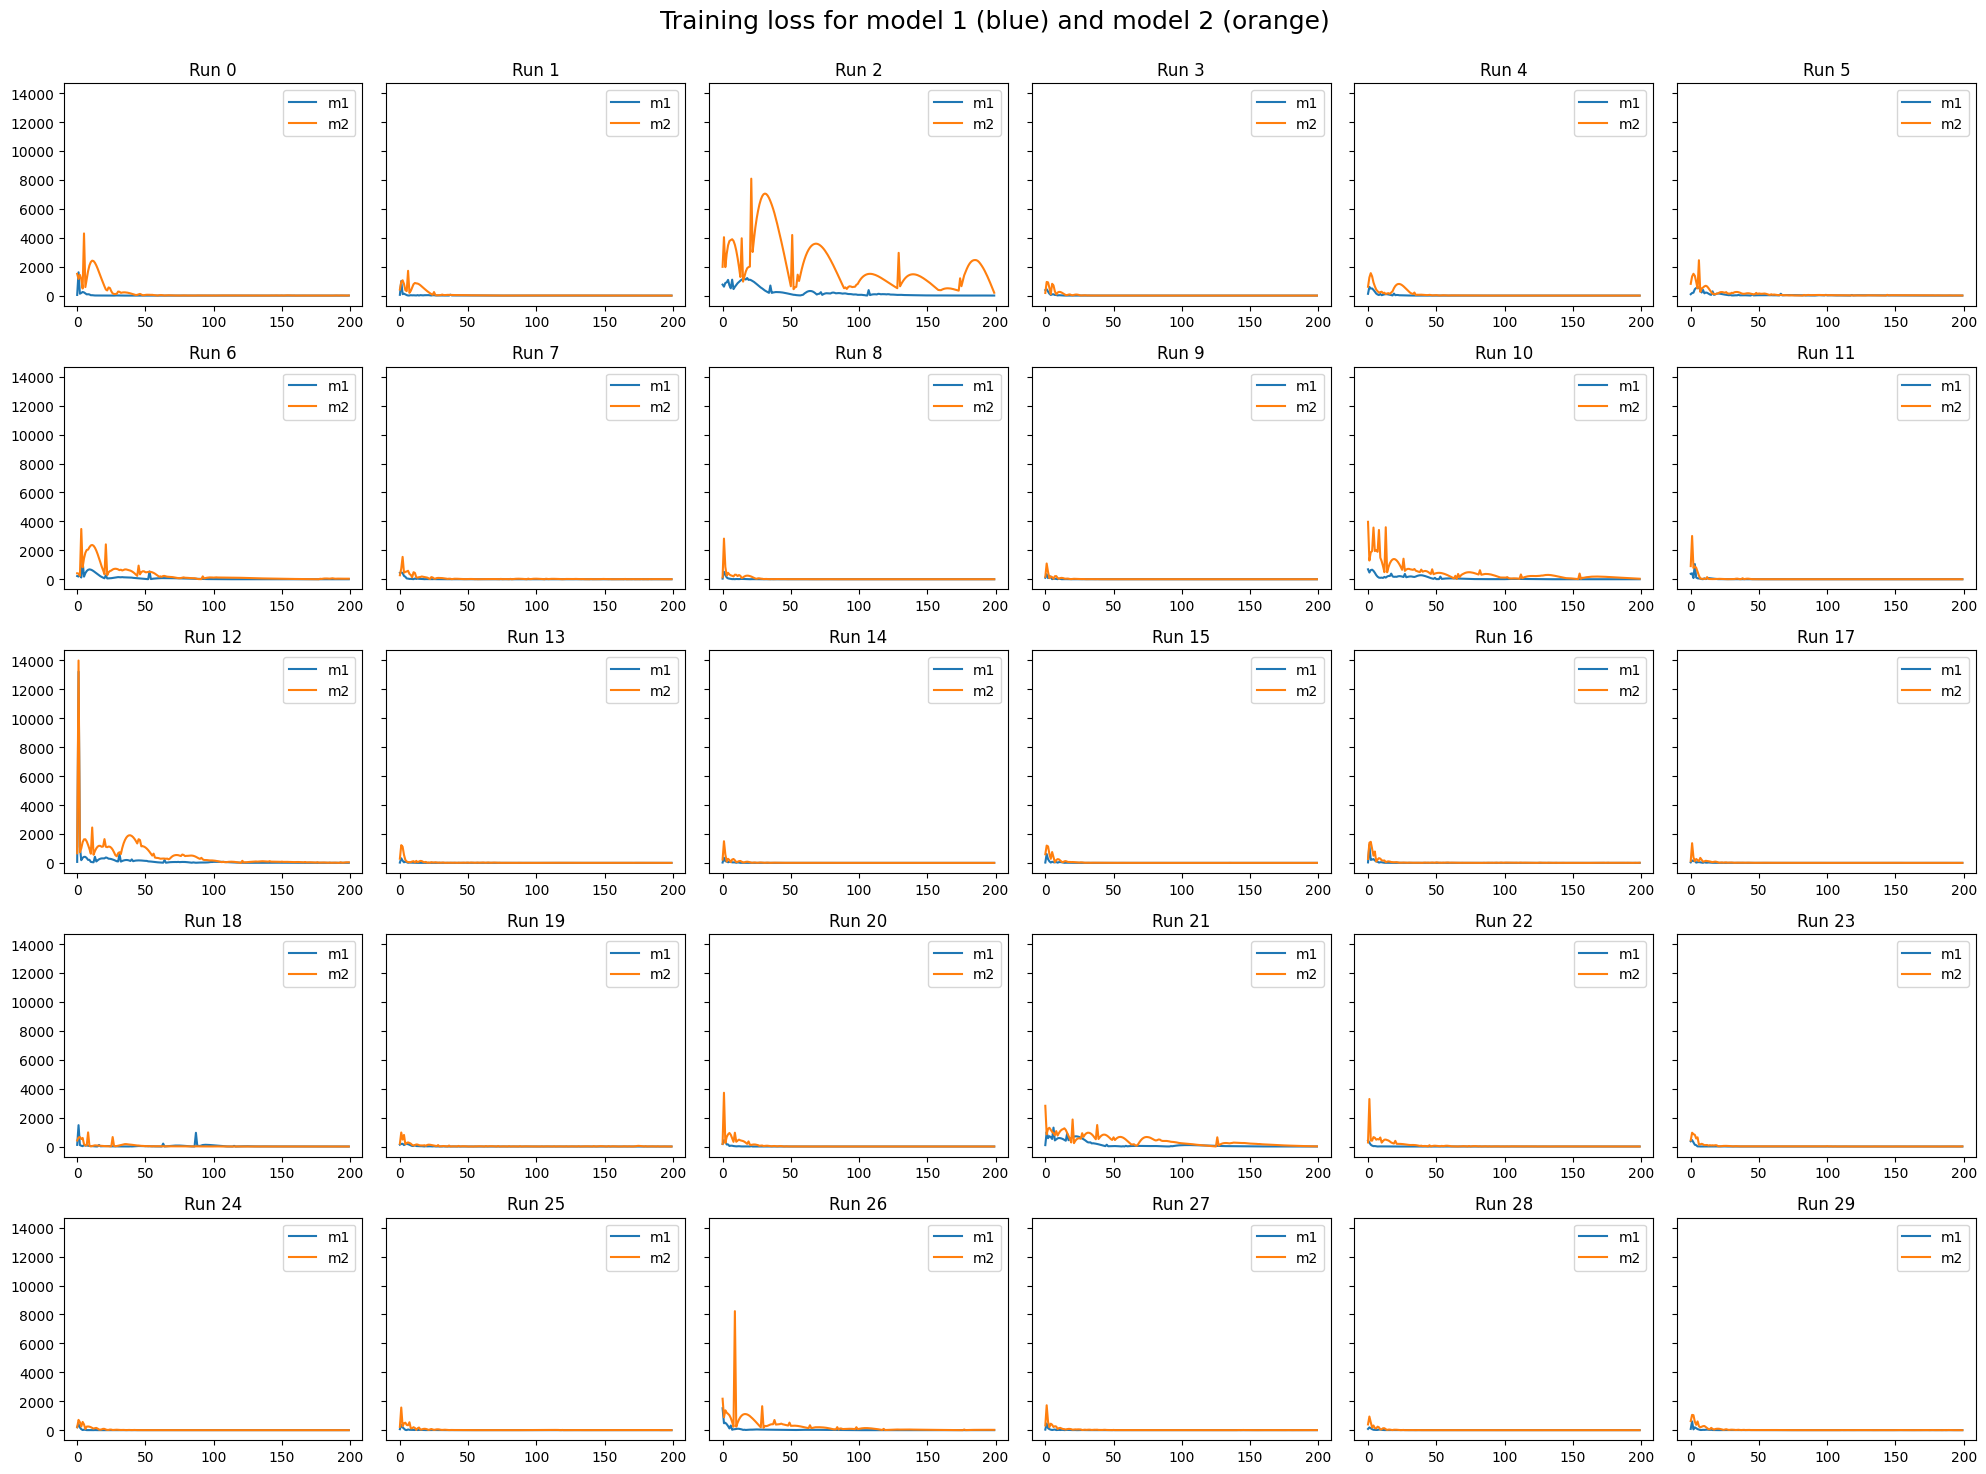

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
#import numpy as np


# Configurar la grilla de 30 plots (5 filas x 6 columnas)
fig, axs = plt.subplots(5, 6, figsize=(20, 15), sharey=True)

# Contador de "runs" para los títulos
run_counter = 0

# Iterar sobre cada par de columnas (0-1, 2-3, ..., 58-59)
for i in range(5):
    for j in range(6):
        # Índices de las columnas a graficar
        col1 = (run_counter * 2)
        col2 = col1 + 1

        # Graficar los valores de las columnas col1 y col2 vs range(200)
        axs[i, j].plot(range(200), df_losses.iloc[:, col1], label='m1')
        axs[i, j].plot(range(200), df_losses.iloc[:, col2], label='m2')

        # Añadir título y leyenda
        axs[i, j].set_title(f'Run {run_counter}')
        axs[i, j].legend()

        # Incrementar el contador de "runs"
        run_counter += 1

fig.suptitle("Training loss for model 1 (blue) and model 2 (orange)\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()


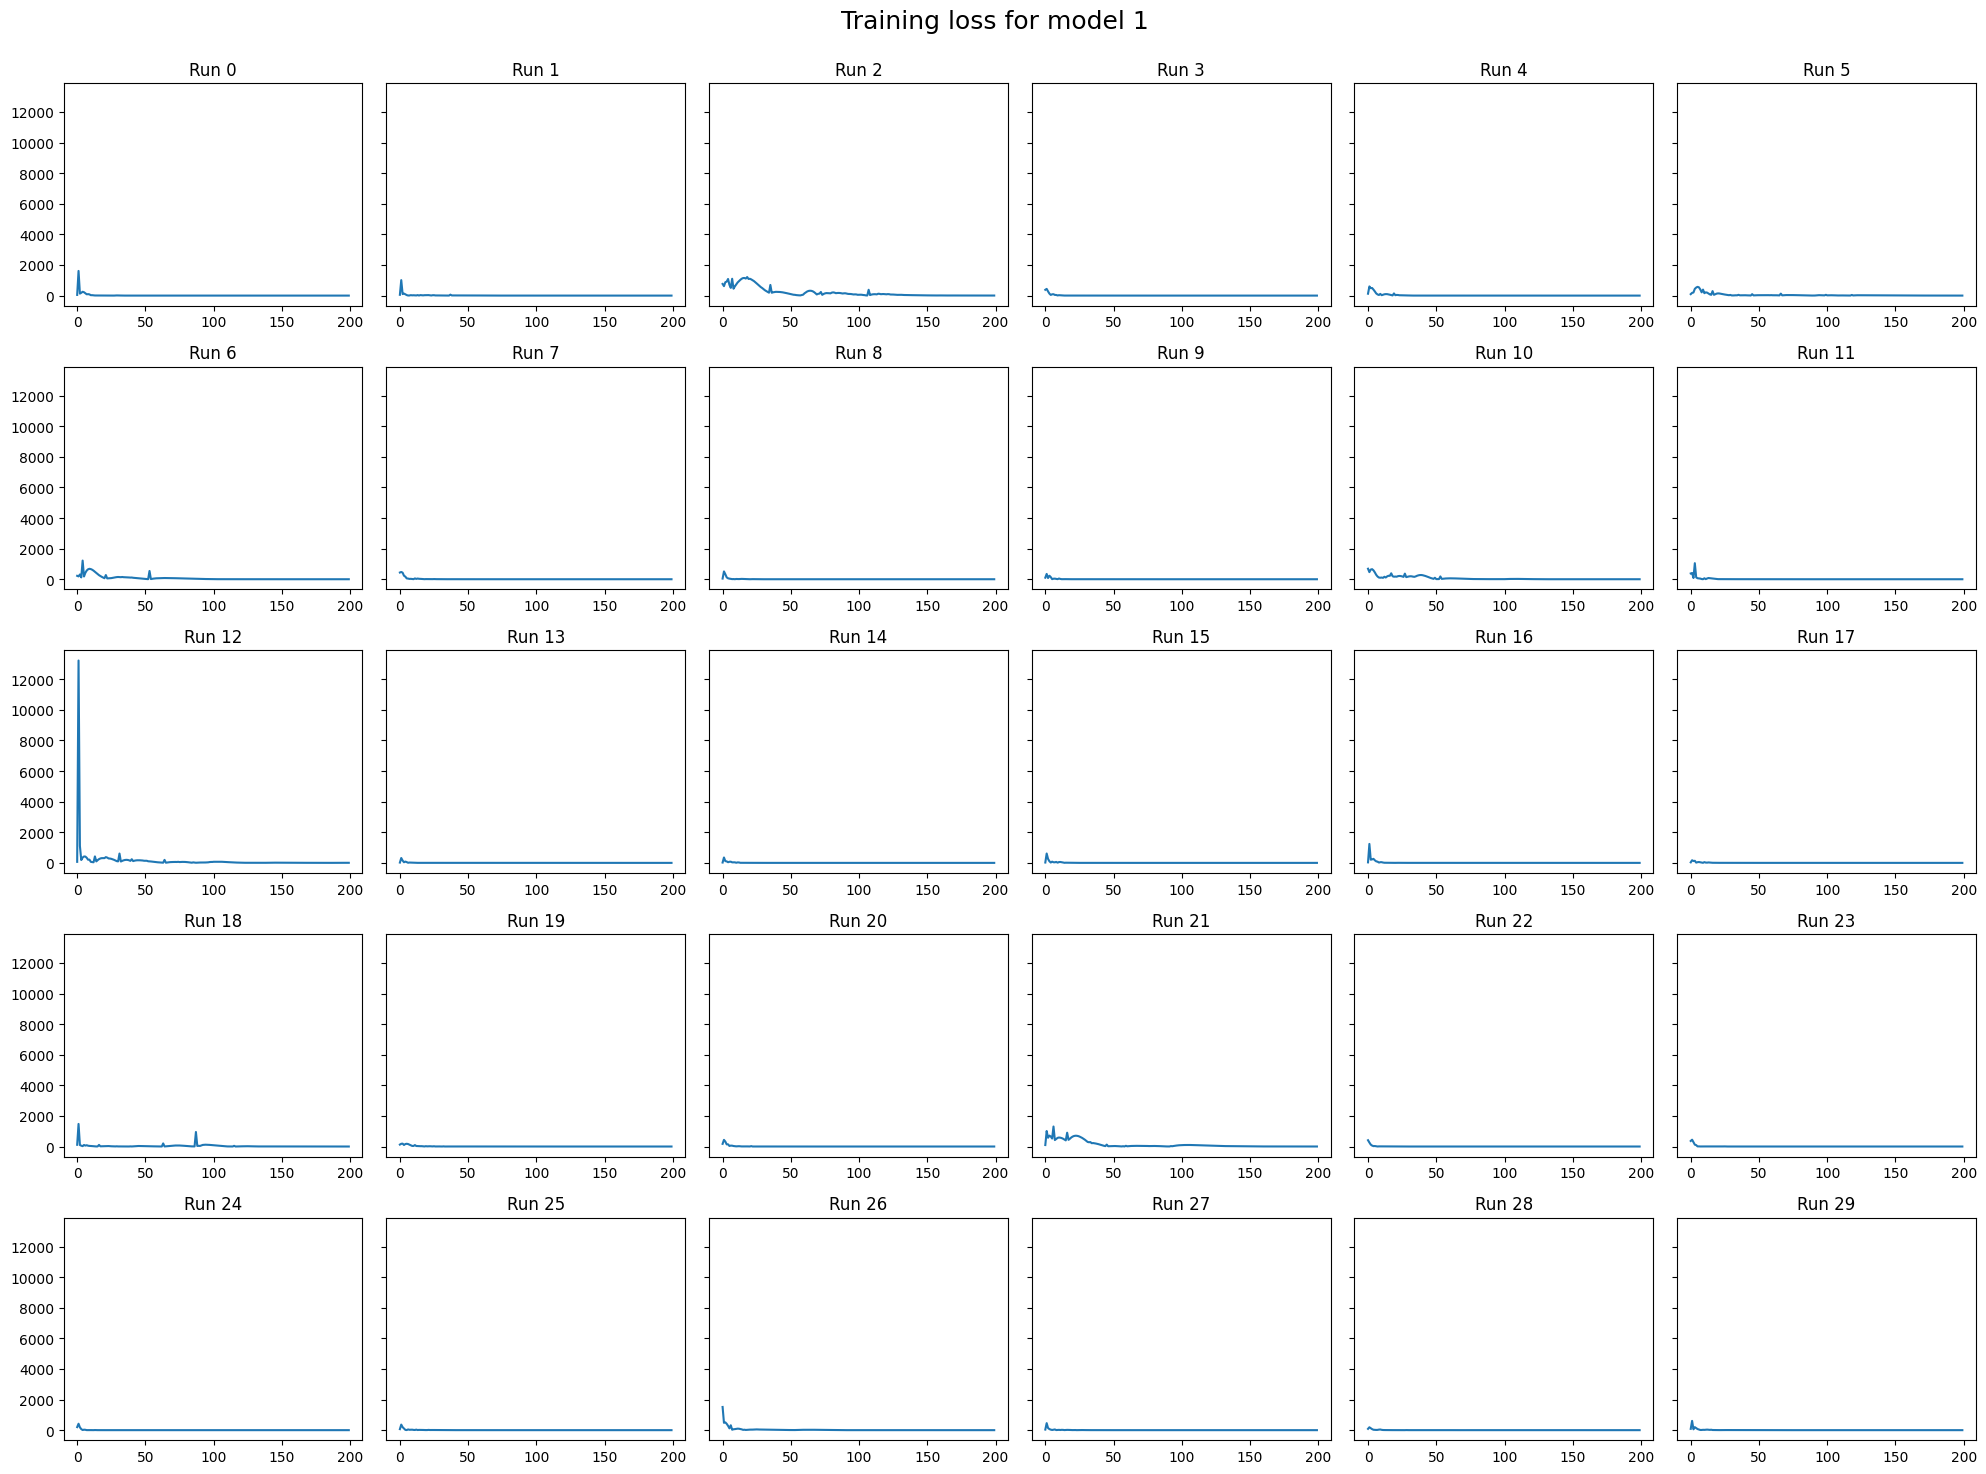

In [ ]:
# Configurar la grilla de 30 plots (5 filas x 6 columnas)
fig, axs = plt.subplots(5, 6, figsize=(20, 15), sharey=True)

# Contador de "runs" para los títulos
run_counter = 0

# Iterar sobre cada par de columnas (0-1, 2-3, ..., 58-59)
for i in range(5):
    for j in range(6):
        # Índices de las columnas a graficar
        col1 = (run_counter * 2)
        col2 = col1 + 1

        # Graficar los valores de las columnas col1 y col2 vs range(200)
        axs[i, j].plot(range(200), df_losses.iloc[:, col1], color='tab:blue')
        #axs[i, j].plot(range(200), df_losses.iloc[:, col2], color='tab:orange') #label='m2')

        #axs[i,j].set_ylim(0, 14000)

        # Añadir título y leyenda
        axs[i, j].set_title(f'Run {run_counter}')

        # Incrementar el contador de "runs"
        run_counter += 1


fig.suptitle('Training loss for model 1\n', fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()


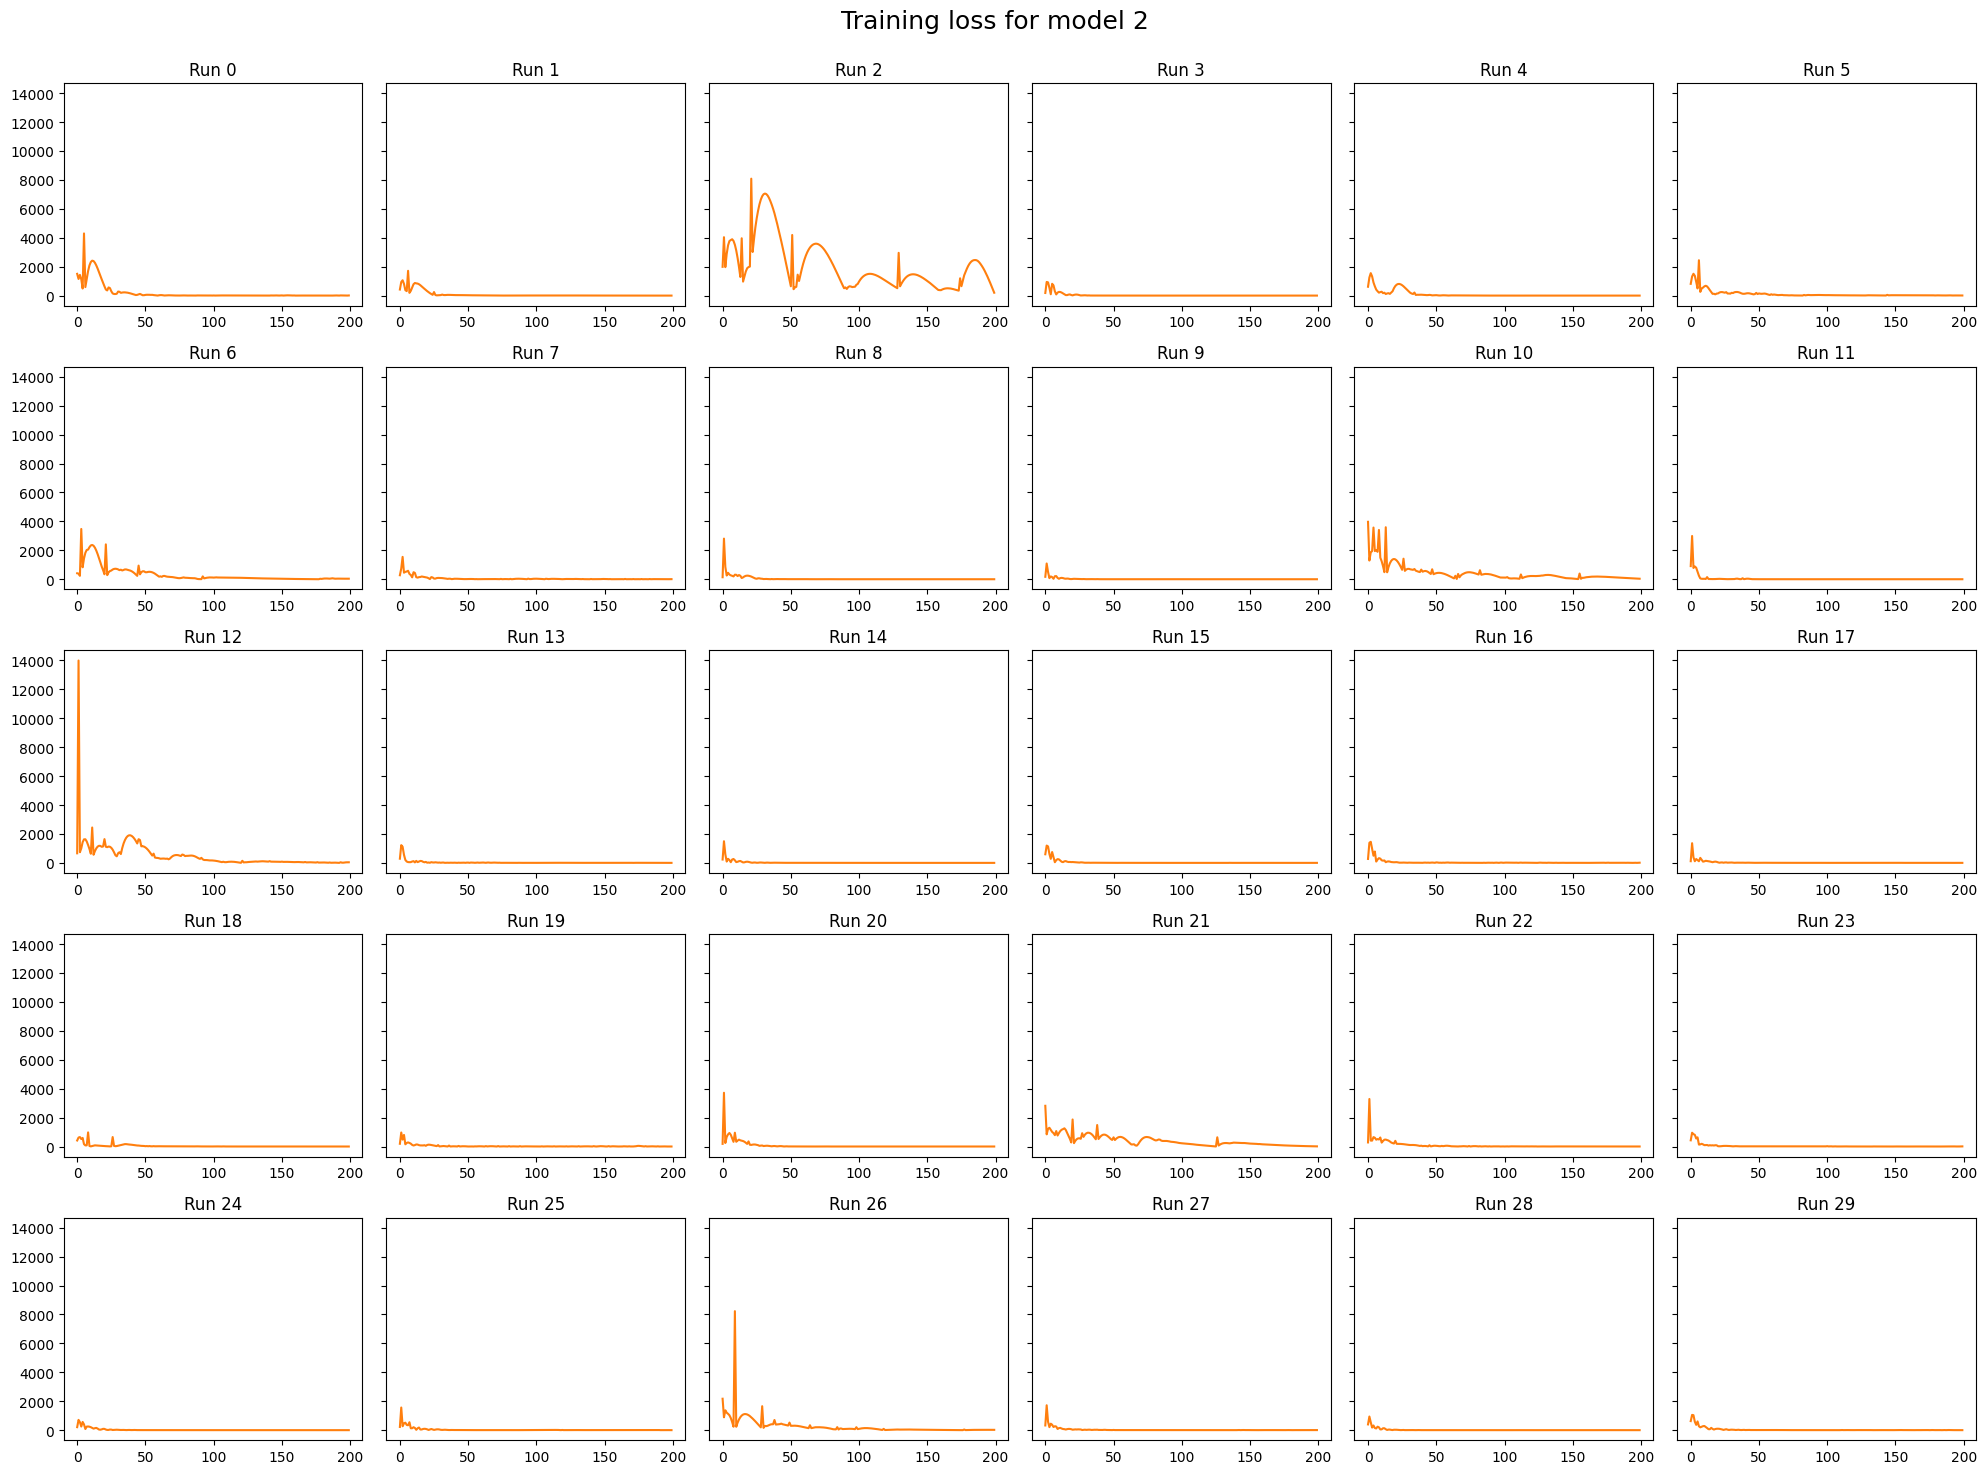

In [ ]:
# Configurar la grilla de 30 plots (5 filas x 6 columnas)
fig, axs = plt.subplots(5, 6, figsize=(20, 15), sharey=True)

# Contador de "runs" para los títulos
run_counter = 0

# Iterar sobre cada par de columnas (0-1, 2-3, ..., 58-59)
for i in range(5):
    for j in range(6):
        # Índices de las columnas a graficar
        col1 = (run_counter * 2)
        col2 = col1 + 1

        # Graficar los valores de las columnas col1 y col2 vs range(200)
        #axs[i, j].plot(range(200), df_losses.iloc[:, col1], color='tab:blue') #label='m1')
        axs[i, j].plot(range(200), df_losses.iloc[:, col2], color='tab:orange') #label='m2')

        # Añadir título y leyenda
        axs[i, j].set_title(f'Run {run_counter}')

        # Incrementar el contador de "runs"
        run_counter += 1

fig.suptitle('Training loss for model 2\n', fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()

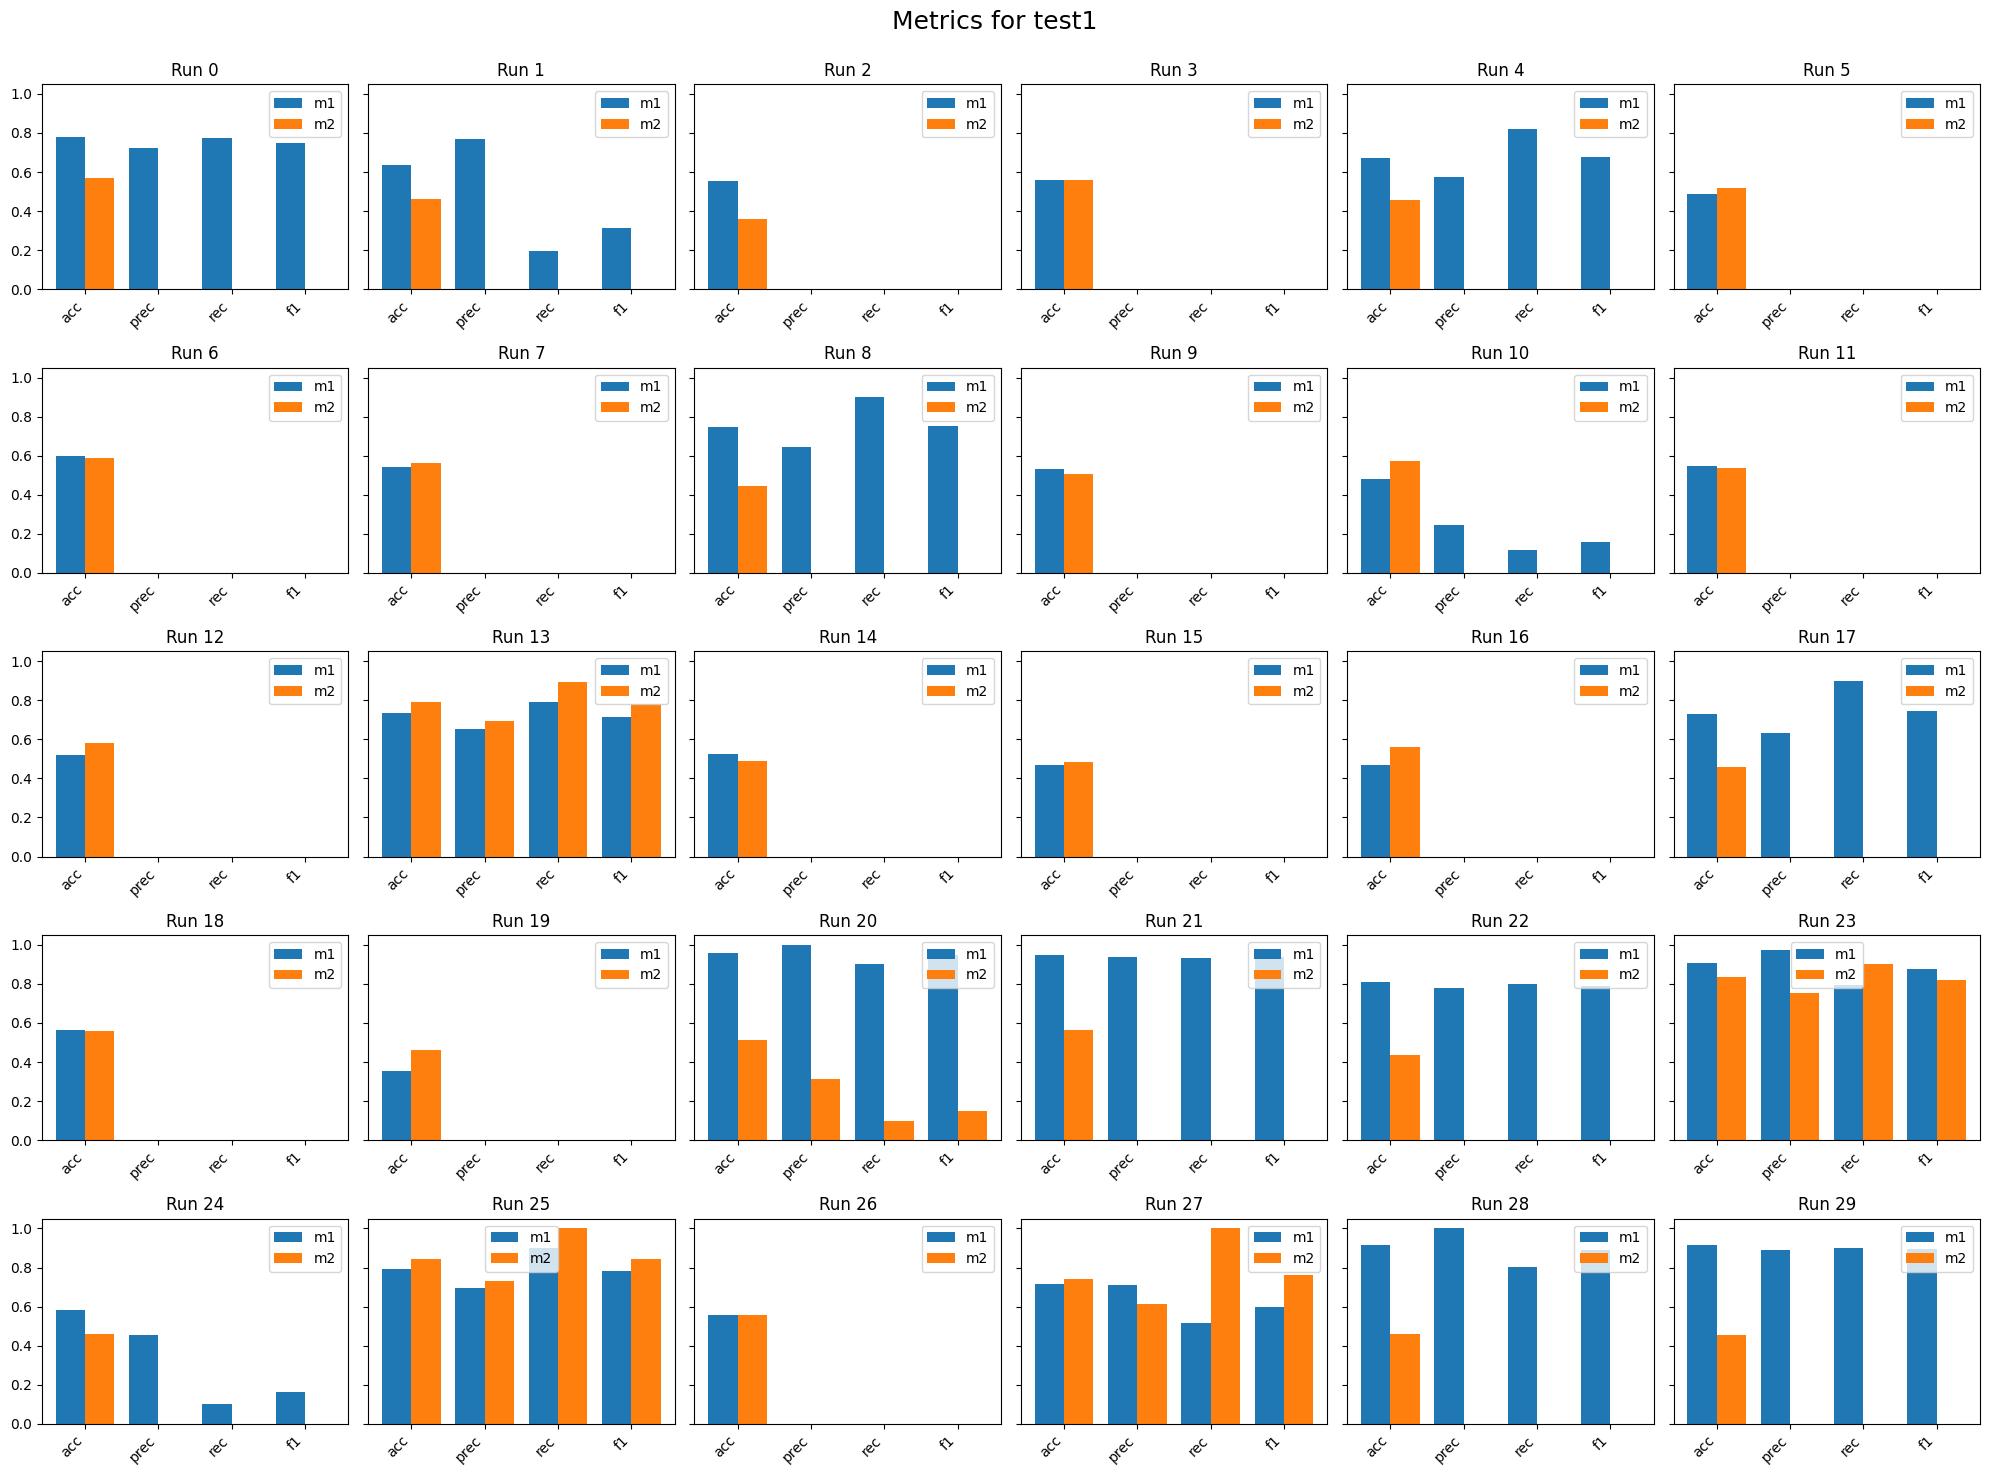

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configurar la grilla de 30 plots (5 filas x 6 columnas)
fig, axs = plt.subplots(5, 6, figsize=(20, 15), sharey=True)

# Nombres para los xticks (las 4 comparaciones)
xtick_labels = ['acc', 'prec', 'rec', 'f1']

# Iterar sobre cada fila del DataFrame
for idx, row in enumerate(df_metrics_test1.iterrows()):
    i, j = divmod(idx, 6)  # Calcular el índice para las subplots (filas y columnas)

    # Extraer los valores de cada fila para graficar
    group_1 = row[1].iloc[[0, 1, 2, 3]]  # Valores 0, 1, 2, 3
    group_2 = row[1].iloc[[4, 5, 6, 7]]  # Valores 4, 5, 6, 7

    # Crear el gráfico de barras comparando los grupos
    axs[i, j].bar(np.arange(4) - 0.2, group_1, width=0.4, label='m1')
    axs[i, j].bar(np.arange(4) + 0.2, group_2, width=0.4, label='m2')

    # Añadir título, xticks y leyenda
    axs[i, j].set_title(f'Run {idx}')
    axs[i, j].set_xticks(np.arange(4))  # Colocar los xticks en las posiciones correctas
    axs[i, j].set_xticklabels(xtick_labels, rotation=45, ha='right')  # Colocar los nombres de los xticks
    axs[i, j].legend()

#axs[0,0].legend()

fig.suptitle("Metrics for test1\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()


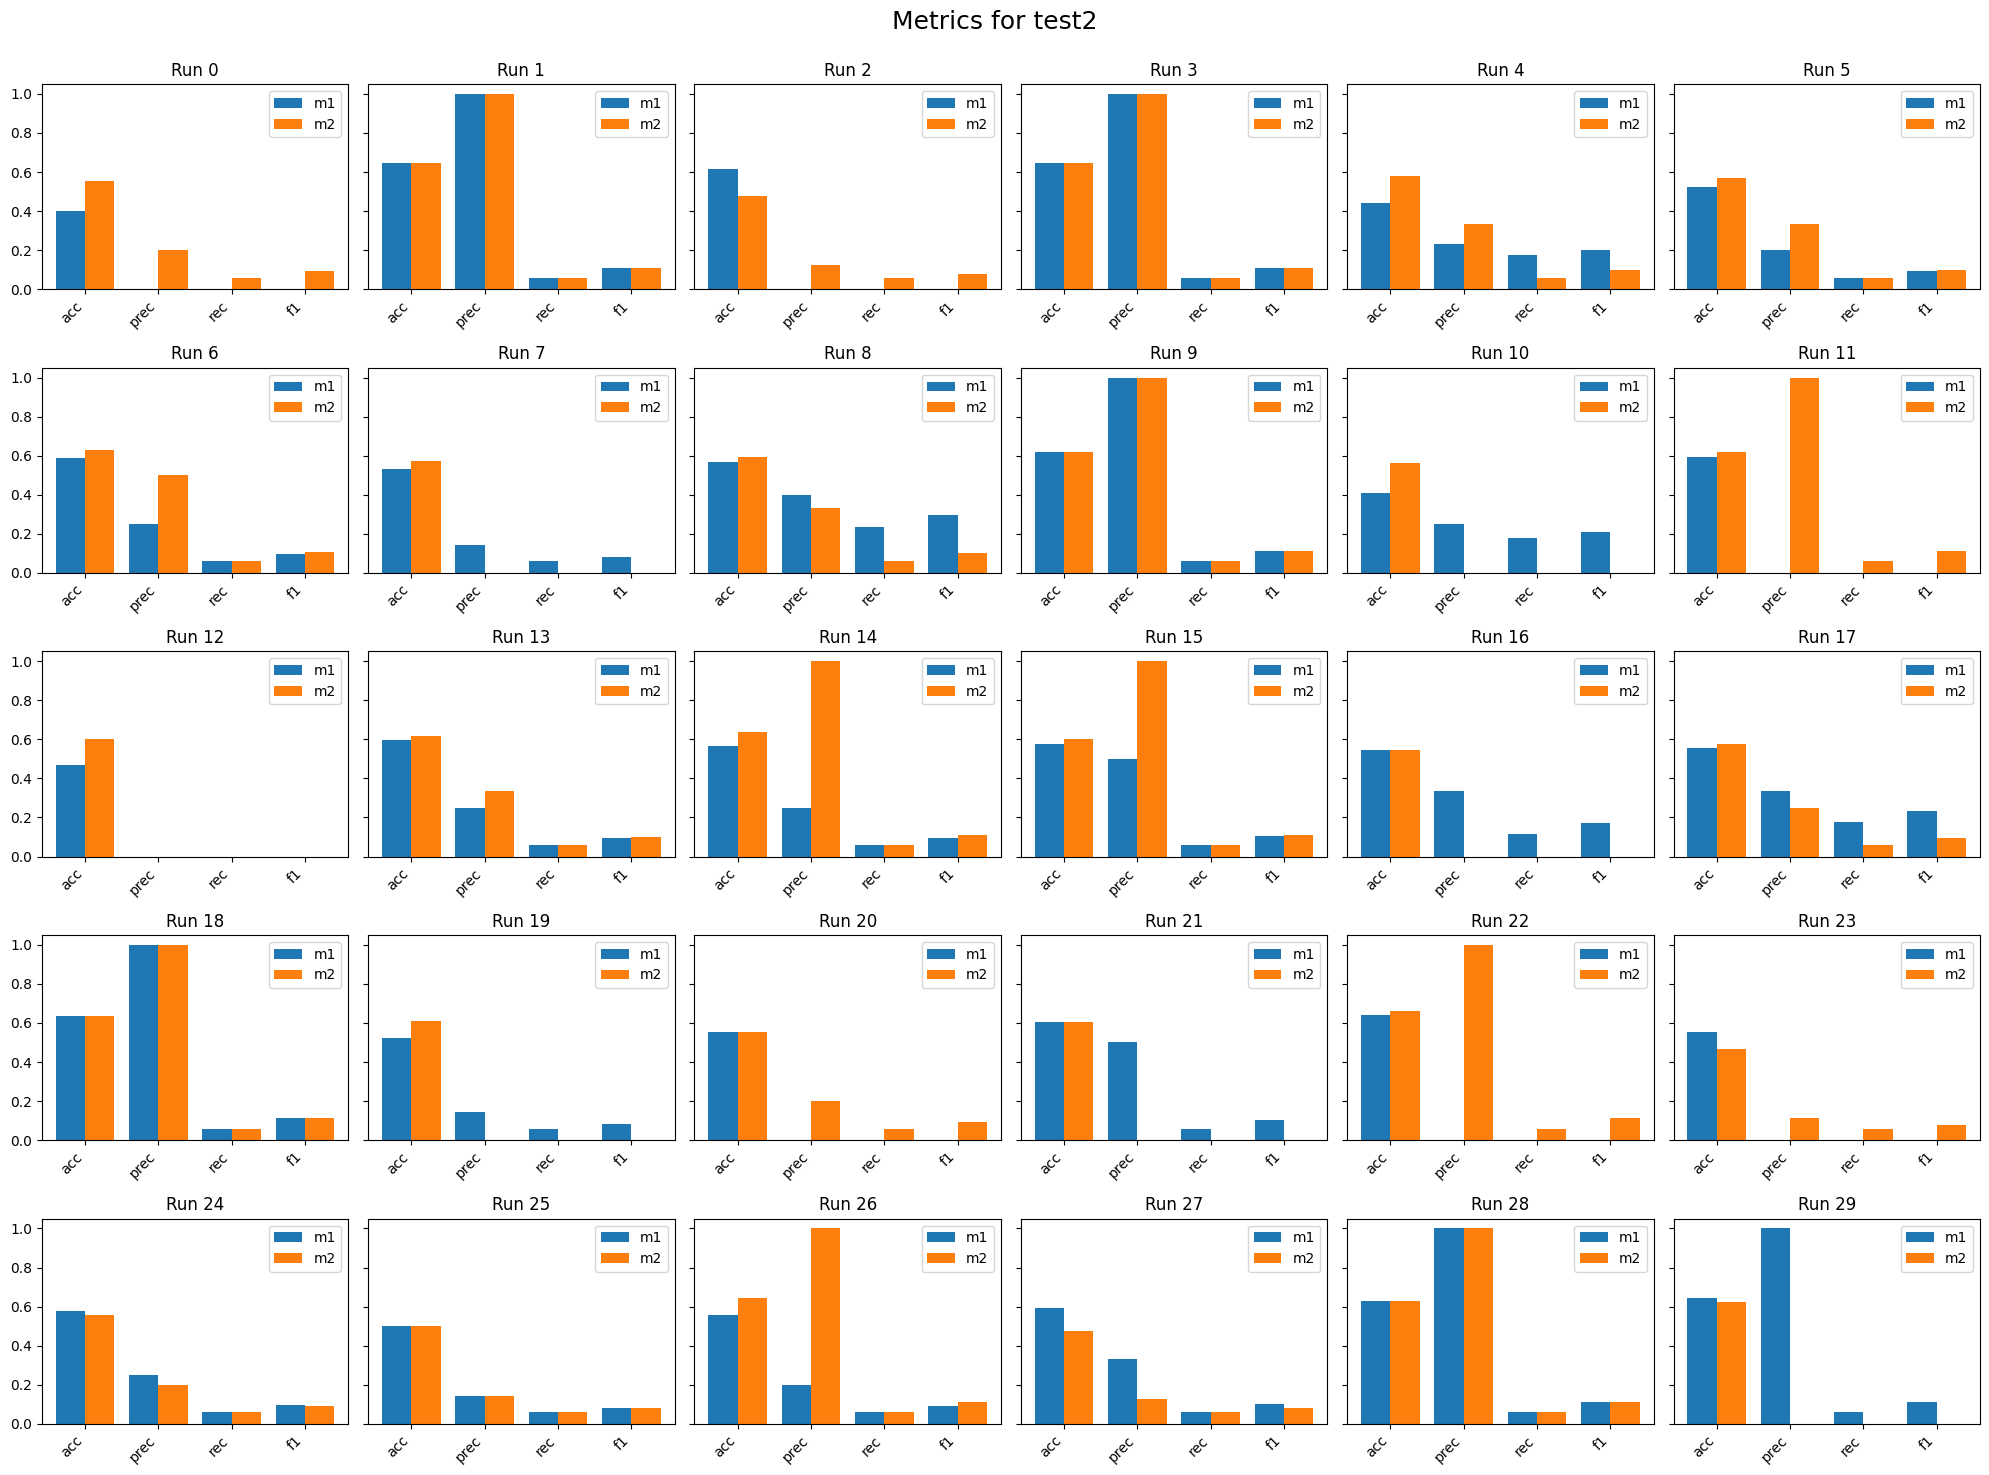

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configurar la grilla de 30 plots (5 filas x 6 columnas)
fig, axs = plt.subplots(5, 6, figsize=(20, 15), sharey=True)

# Nombres para los xticks (las 4 comparaciones)
xtick_labels = ['acc', 'prec', 'rec', 'f1']

# Iterar sobre cada fila del DataFrame
for idx, row in enumerate(df_metrics_test2.iterrows()):
    i, j = divmod(idx, 6)  # Calcular el índice para las subplots (filas y columnas)

    # Extraer los valores de cada fila para graficar
    group_1 = row[1].iloc[[0, 1, 2, 3]]  # Valores 0, 1, 2, 3
    group_2 = row[1].iloc[[4, 5, 6, 7]]  # Valores 4, 5, 6, 7

    # Crear el gráfico de barras comparando los grupos
    axs[i, j].bar(np.arange(4) - 0.2, group_1, width=0.4, label='m1')
    axs[i, j].bar(np.arange(4) + 0.2, group_2, width=0.4, label='m2')

    # Añadir título, xticks y leyenda
    axs[i, j].set_title(f'Run {idx}')
    axs[i, j].set_xticks(np.arange(4))  # Colocar los xticks en las posiciones correctas
    axs[i, j].set_xticklabels(xtick_labels, rotation=45, ha='right')  # Colocar los nombres de los xticks
    axs[i, j].legend()

#axs[0,0].legend()

fig.suptitle("Metrics for test2\n", fontsize=18)
# Ajustar el layout para evitar solapamientos
plt.tight_layout()

# Mostrar la figura
plt.show()

# Exploring training dataloader

In [ ]:
import pickle

with open('/content/subsets.pkl', 'rb') as archivo:
    subsets = pickle.load(archivo)

In [ ]:
train_data = Data(
      x = subsets[2]["15-3"]["node_features_tensor"],       # Node features
      edge_index = subsets[2]["15-3"]["edge_indices"],      # Edge index
      edge_attr = subsets[2]["15-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[2]["15-3"]["edge_labels_tensor"]   # Edge labels
    )
train_loader1 = DataLoader([train_data], batch_size=1, shuffle=True)
train_loader2 = DataLoader([train_data], batch_size=1, shuffle=True)
train_loader3 = DataLoader([train_data], batch_size=1, shuffle=False)

for data in train_loader1:
  x1=data.x
  print("x:\n", data.x)
  edge_index1 = data.edge_index
  print("edge_index:\n", data.edge_index)
  edge_attr1 = data.edge_attr
  print("edge_attr:\n", data.edge_attr)

for data in train_loader2:
  x2=data.x
  print("x:\n", data.x)
  edge_index2 = data.edge_index
  print("edge_index:\n", data.edge_index)
  edge_attr2 = data.edge_attr
  print("edge_attr:\n", data.edge_attr)

for data in train_loader3:
  x3=data.x
  print("x:\n", data.x)
  edge_index3 = data.edge_index
  print("edge_index:\n", data.edge_index)
  edge_attr3 = data.edge_attr
  print("edge_attr:\n", data.edge_attr)

x:
 tensor([[3.8062e+00, 7.5117e+02, 5.2536e+02,  ..., 6.0000e+01, 0.0000e+00,
         0.0000e+00],
        [1.0000e+00, 7.8667e+01, 3.6667e+01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [3.2333e+01, 1.1735e+04, 9.5610e+03,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.2400e+02, 4.0000e+01,
         4.7500e-04],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])
edge_index:
 tensor([[686, 740, 433,  ..., 551, 409, 331],
        [ 10,  10,  10,  ...,  10,  10,  10]])
edge_attr:
 tensor([[1.4920e-03, 2.0000e+00, 5.2300e+02, 4.3800e+02, 6.7024e+02],
        [4.6200e+00, 1.5000e+01, 1.0500e+03, 0.0000e+00, 3.0303e+00],
        [4.0300e-04, 2.0000e+00, 1.3300e+02, 4.9000e+01, 2.4814e+03],
        ...,
        [6.2800e-04, 2.0000e+00, 1.2800e+02, 4.4000e+01, 1.

In [ ]:
(x1==x3).all()

tensor(True)

In [ ]:
for j in range(0,30):
    print(j)

    train_data = Data(
      x = subsets[j]["15-3"]["node_features_tensor"],       # Node features
      edge_index = subsets[j]["15-3"]["edge_indices"],      # Edge index
      edge_attr = subsets[j]["15-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[j]["15-3"]["edge_labels_tensor"]   # Edge labels
    )
    train_loader1 = DataLoader([train_data], batch_size=1, shuffle=True)
    train_loader2 = DataLoader([train_data], batch_size=1, shuffle=True)

    for data in train_loader1:
        x1=data.x
        edge_index1 = data.edge_index
        edge_attr1 = data.edge_attr
    for data in train_loader2:
        x2=data.x
        edge_index2 = data.edge_index
        edge_attr2 = data.edge_attr
    if not (x2==x1).all():
      print("x:",j)
    if not (edge_index2==edge_index1).all():
      print("edge_index:",j)
    if not (edge_attr2==edge_attr1).all():
      print("edge_attr:",j)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [ ]:
train_loader1 = DataLoader([train_data], batch_size=1, shuffle=True)
train_loader2 = DataLoader([train_data], batch_size=2, shuffle=True)

In [ ]:
#from torch_geometric.loader import DataLoader

for j in range(0,30):
    print(j)

    train_data = Data(
      x = subsets[j]["15-3"]["node_features_tensor"],       # Node features
      edge_index = subsets[j]["15-3"]["edge_indices"],      # Edge index
      edge_attr = subsets[j]["15-3"]["edge_features_tensor"],  # Edge features
      edge_label = subsets[j]["15-3"]["edge_labels_tensor"]   # Edge labels
    )
    for batch1, batch2 in zip(train_loader1, train_loader2):
        print(batch1)
        print(batch2)

        # Compare the node features (x)
        # print("Batch 1 node features:", batch1.x)
        # print("Batch 2 node features:", batch2.x)

        # # Compare the edge indices
        # print("Batch 1 edge index:", batch1.edge_index)
        # print("Batch 2 edge index:", batch2.edge_index)

        # # You can also compare edge attributes, labels, etc.
        # print("Batch 1 edge attributes:", batch1.edge_attr)
        # print("Batch 2 edge attributes:", batch2.edge_attr)

        # Add any specific comparison logic here
        # Example: Check if the two batches are equal
        print("Batches are equal:", torch.equal(batch1.x, batch2.x) and
              torch.equal(batch1.edge_index, batch2.edge_index) and
              torch.equal(batch1.edge_attr, batch2.edge_attr))

        # If you want to stop after comparing the first batch
        #break


0
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
Batches are equal: True
1
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
Batches are equal: True
2
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
Batches are equal: True
3
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
DataBatch(x=[3491, 8], edge_index=[2, 3468], edge_attr=[3468, 5], edge_label=[3468], batch=[3491], ptr=[2])
Batches are equal: True
4
DataBatch(x=[3491, 8], edge_in